# Branch And Bound 

## Import Library 

In [58]:
import math
import time
import heapq
import numpy as np
from scipy.optimize import linprog
from copy import deepcopy

## Read Data

In [59]:
def read_solomon_file(filepath: str) -> dict:
    with open(filepath, "r") as f:
        lines = [ln.strip() for ln in f if ln.strip()]

    # Dòng chứa số xe và sức chứa
    n_vehicles = capacity = None
    data_rows  = []

    i = 0
    while i < len(lines):
        parts = lines[i].split()
        # Tìm dòng "25  200" (vehicle number + capacity)
        if (n_vehicles is None and len(parts) == 2
                and parts[0].isdigit() and parts[1].isdigit()):
            n_vehicles = int(parts[0])
            capacity   = int(parts[1])
        # Dòng dữ liệu khách hàng: 7 số
        elif len(parts) == 7 and parts[0].isdigit():
            data_rows.append([int(v) for v in parts])
        i += 1

    customers = [
        {
            "id":      r[0],
            "x":       r[1],
            "y":       r[2],
            "demand":  r[3], # nhu cau
            "ready":   r[4],
            "due":     r[5],
            "service": r[6],
        }
        for r in data_rows
    ]

    return {
        "n_vehicles": n_vehicles,
        "capacity":   capacity,
        "customers":  customers,   # index 0 = depot
    }

## Build Data

In [60]:
def build_problem(raw: dict, n_customers: int) -> dict:
    """
    Xây dựng dict bài toán VRPTW từ raw data Solomon.

    Trả về dict gồm:
        nodes, depot, customers, demand, ready, due, service,
        dist, capacity, n_vehicles, arcs, n, M_time, _coords
    """
    rows  = raw["customers"][: n_customers + 1]   # depot + n_customers
    nodes = [r["id"] for r in rows]

    x_coord = {r["id"]: r["x"]       for r in rows}
    y_coord = {r["id"]: r["y"]       for r in rows}
    demand  = {r["id"]: r["demand"]  for r in rows}
    ready   = {r["id"]: r["ready"]   for r in rows}
    due     = {r["id"]: r["due"]     for r in rows}
    service = {r["id"]: r["service"] for r in rows}

    # c_ij = t_ij = khoảng cách Euclidean (tốc độ = 1)
    dist = {
        (i, j): math.hypot(x_coord[i] - x_coord[j], y_coord[i] - y_coord[j])
        for i in nodes for j in nodes if i != j
    }

    arcs = [(i, j) for i in nodes for j in nodes if i != j]
    n    = len(nodes)   # tổng số nút (depot + khách hàng)

    # Big-M theo công thức: M_ij = b_i + s_i + t_ij - a_j
    M_time = {
        (i, j): max(0.0, due[i] + service[i] + dist[(i, j)] - ready[j])
        for (i, j) in arcs
    }

    # Lưu tọa độ để dùng cho visualization
    _coords = {r["id"]: (r["x"], r["y"]) for r in rows}

    return {
        "nodes":      nodes,
        "depot":      nodes[0],
        "customers":  nodes[1:],
        "demand":     demand,
        "ready":      ready,
        "due":        due,
        "service":    service,
        "dist":       dist,
        "capacity":   raw["capacity"],
        "n_vehicles": raw["n_vehicles"],
        "arcs":       arcs,
        "n":          n,
        "M_time":     M_time,
        "_coords":    _coords,   # tọa độ (x, y) cho mỗi node
    }


## Giải LP Relataxion 

In [61]:
def solve_lp_relaxation(problem: dict,
                         fix_to_zero: set,
                         fix_to_one:  set) -> dict:
    """
    Giải LP Relaxation của mô hình VRPTW tại một nút B&B.

    Mô hình LP (Two-index formulation chuẩn):
        Biến: x[a] cho mỗi cung a=(i,j), s[i] thời gian bắt đầu phục vụ, u[i] tải tích lũy
        Hàm mục tiêu: min  sum_a c_a * x_a
        Ràng buộc:
            (1) sum_{j} x_{ij} = 1                    forall i in customers    (mỗi KH ra đúng 1 lần)
            (2) sum_{j} x_{hj} - sum_{i} x_{ih} = 0  forall h in customers    (bảo toàn luồng)
            (3a) sum_{j in C} x_{0j} <= m                                      (số xe xuất phát tối đa)
            (3b) sum_{i in C} x_{i0} <= m                                      (số xe về tối đa — FIX mới)
            (4) a_i <= s_i <= b_i                     forall i in nodes        (time window, encoded in bounds)
            (5) s_i + serv_i + t_ij - s_j <= M_ij*(1-x_ij)  forall (i,j) in arcs  (thứ tự thời gian)
                <=> s_i - s_j + M_ij * x_ij <= M_ij - t_ij - serv_i
                Đặc biệt khi j=depot: s_i + M_ij*x_ij <= M_ij + due[depot] - t_ij - serv_i
            (6) u_i + q_j - u_j <= Q*(1-x_ij)        forall (i,j), j != depot (sức chứa)
                <=> u_i - u_j + Q * x_ij <= Q - q_j
            (7) q_i <= u_i <= Q                       forall i in customers    (bounds)
            (8) 0 <= x_ij <= 1                                                 (nới lỏng nguyên)
            (+) x_ij = 0 nếu (i,j) in fix_to_zero
            (+) x_ij = 1 nếu (i,j) in fix_to_one

    Tham số
    -------
    problem      : dict từ build_problem()
    fix_to_zero  : tập cung (i,j) bị ép x_ij = 0 (nhánh trái)
    fix_to_one   : tập cung (i,j) bị ép x_ij = 1 (nhánh phải)

    Trả về
    ------
    dict: status ('optimal'/'infeasible'), obj, x_val, s_val, u_val
    """
    nodes      = problem["nodes"]
    customers  = problem["customers"]
    depot      = problem["depot"]
    arcs       = problem["arcs"]
    dist       = problem["dist"]
    ready      = problem["ready"]
    due        = problem["due"]
    demand     = problem["demand"]
    service    = problem["service"]
    capacity   = problem["capacity"]
    n_vehicles = problem["n_vehicles"]
    M_time     = problem["M_time"]
    n          = problem["n"]          # số nút
    na         = len(arcs)             # số cung

    # -------------------------------------------------------------------
    # Lập index:
    #   x[a]  : cột 0..na-1          (na biến)
    #   s[i]  : cột na..na+n-1       (n biến)
    #   u[i]  : cột na+n..na+2n-1   (n biến)
    # -------------------------------------------------------------------
    arc_idx  = {a: k    for k, a in enumerate(arcs)}
    node_idx = {v: k    for k, v in enumerate(nodes)}
    n_vars   = na + n + n

    def ix(a):  return arc_idx[a]           # index của x_a
    def is_(v): return na + node_idx[v]     # index của s_v
    def iu(v):  return na + n + node_idx[v] # index của u_v

    # -------------------------------------------------------------------
    # Hàm mục tiêu: min sum c_ij * x_ij   (s, u có hệ số 0)
    # -------------------------------------------------------------------
    c_obj = np.zeros(n_vars)
    for a in arcs:
        c_obj[ix(a)] = dist[a]

    # -------------------------------------------------------------------
    # Bounds
    # -------------------------------------------------------------------
    bounds = [None] * n_vars

    # x_ij in [0, 1]
    for a in arcs:
        lo, hi = 0.0, 1.0
        if a in fix_to_zero: lo = hi = 0.0
        if a in fix_to_one:  lo = hi = 1.0
        bounds[ix(a)] = (lo, hi)

    # s_i in [a_i, b_i]
    for v in nodes:
        bounds[is_(v)] = (float(ready[v]), float(due[v]))

    # u_depot = 0 (depot không mang hàng)
    bounds[iu(depot)] = (0.0, 0.0)
    # u_i in [q_i, Q] cho khách hàng
    for v in customers:
        bounds[iu(v)] = (float(demand[v]), float(capacity))

    # -------------------------------------------------------------------
    # Ràng buộc bằng (equality): A_eq @ z = b_eq
    # (1) sum_{j: j!=i} x_{ij} = 1  forall i in customers
    # (2) sum_{j} x_{hj} - sum_{i} x_{ih} = 0  forall h in customers
    # -------------------------------------------------------------------
    A_eq_rows, b_eq = [], []

    # Ràng buộc (1): mỗi khách hàng xuất đi đúng 1 lần
    for i in customers:
        row = np.zeros(n_vars)
        for j in nodes:
            if j != i and (i, j) in arc_idx:
                row[ix((i, j))] = 1.0
        A_eq_rows.append(row)
        b_eq.append(1.0)

    # Ràng buộc (2): bảo toàn luồng tại mỗi khách hàng (out - in = 0)
    for h in customers:
        row = np.zeros(n_vars)
        for j in nodes:
            if j != h and (h, j) in arc_idx:
                row[ix((h, j))] += 1.0   # ra khỏi h
        for i in nodes:
            if i != h and (i, h) in arc_idx:
                row[ix((i, h))] -= 1.0   # vào h
        A_eq_rows.append(row)
        b_eq.append(0.0)

    A_eq = np.array(A_eq_rows) if A_eq_rows else None
    b_eq = np.array(b_eq)

    # -------------------------------------------------------------------
    # Ràng buộc bất đẳng thức (upper bound): A_ub @ z <= b_ub
    # (3a) sum_{j in C} x_{0j} <= m   (số xe xuất phát)
    # (3b) sum_{i in C} x_{i0} <= m   (số xe về depot)   ← FIX: thêm mới
    # (5)  s_i + serv_i + t_ij - s_j <= M_ij*(1 - x_ij)
    #      => s_i - s_j + M_ij * x_ij <= M_ij - t_ij - serv_i
    #      Trường hợp j=depot: s_j không bị ràng buộc nhất quán với route,
    #      nên viết: s_i + M_ij*x_ij <= M_ij + due[depot] - t_ij - serv_i
    # (6)  u_i - u_j + Q * x_ij <= Q - q_j  (bỏ qua j=depot vì u_depot=0 là giả)
    # -------------------------------------------------------------------
    A_ub_rows, b_ub = [], []

    # Ràng buộc (3a): số xe xuất phát từ depot tối đa
    row = np.zeros(n_vars)
    for j in customers:
        if (depot, j) in arc_idx:
            row[ix((depot, j))] = 1.0
    A_ub_rows.append(row)
    b_ub.append(float(n_vehicles))

    # FIX (3b): số xe về depot tối đa — đảm bảo đối xứng với (3a)
    row = np.zeros(n_vars)
    for i in customers:
        if (i, depot) in arc_idx:
            row[ix((i, depot))] = 1.0
    A_ub_rows.append(row)
    b_ub.append(float(n_vehicles))

    # Ràng buộc (5): thứ tự thời gian
    # Công thức chuẩn: s_i + serv_i + t_ij <= s_j + M_ij*(1 - x_ij)
    # => s_i - s_j + M_ij * x_ij <= M_ij - t_ij - serv_i
    # Trường hợp đặc biệt j == depot:
    #   Không dùng s_depot trong ràng buộc (s_depot chỉ đại diện thời gian
    #   xuất phát lần đầu, không phải lần về). Thay bằng:
    #   s_i + serv_i + t_i0 <= due[depot]  khi x_i0 = 1
    #   => s_i + M_ij * x_ij <= M_ij + due[depot] - t_ij - serv_i   ← FIX: thêm serv_i
    for (i, j) in arcs:
        M_ij   = M_time[(i, j)]
        t_ij   = dist[(i, j)]
        serv_i = float(service[i])   # FIX: luôn dùng service[i], kể cả depot (=0)
        row    = np.zeros(n_vars)

        if j == depot:
            # FIX: ràng buộc đúng — s_i + serv_i + t_ij <= due[depot] khi x_ij=1
            # => s_i + M_ij * x_ij <= M_ij + due[depot] - t_ij - serv_i
            row[is_(i)]     =  1.0
            # Không đưa s_depot vào — depot return không cần thứ tự thời gian
            row[ix((i, j))] =  M_ij
            A_ub_rows.append(row)
            b_ub.append(M_ij + float(due[depot]) - t_ij - serv_i)

        else:
            # FIX: thống nhất dùng serv_i cho cả i=depot và i=customer
            # s_i - s_j + M_ij * x_ij <= M_ij - t_ij - serv_i
            row[is_(i)]     =  1.0
            row[is_(j)]     = -1.0
            row[ix((i, j))] =  M_ij
            A_ub_rows.append(row)
            b_ub.append(M_ij - t_ij - serv_i)

    # Ràng buộc (6): sức chứa
    # u_i + q_j - u_j <= Q * (1 - x_ij)
    # => u_i - u_j + Q * x_ij <= Q - q_j
    # Bỏ qua j=depot: u_depot=0 là giả (depot không có nhu cầu và
    # tải được reset khi xe về depot — tải chỉ tăng trong 1 route).
    Q = float(capacity)
    for (i, j) in arcs:
        if j == depot:
            continue  # skip: tải không tích lũy qua depot
        q_j = float(demand[j])
        row = np.zeros(n_vars)
        row[iu(i)]      =  1.0
        row[iu(j)]      = -1.0
        row[ix((i, j))] =  Q
        A_ub_rows.append(row)
        b_ub.append(Q - q_j)

    A_ub = np.array(A_ub_rows) if A_ub_rows else None
    b_ub = np.array(b_ub)

    # -------------------------------------------------------------------
    # Gọi HiGHS solver qua scipy.optimize.linprog
    # -------------------------------------------------------------------
    result = linprog(
        c_obj,
        A_ub=A_ub, b_ub=b_ub,
        A_eq=A_eq, b_eq=b_eq,
        bounds=bounds,
        method="highs",
        options={"disp": False, "time_limit": 1800},
    )

    if result.status != 0:   # không tìm được nghiệm khả thi
        return {"status": "infeasible"}

    # Trích xuất giá trị nghiệm
    z       = result.x
    x_val   = {a: z[ix(a)]   for a in arcs}
    s_val   = {v: z[is_(v)]  for v in nodes}
    u_val   = {v: z[iu(v)]   for v in nodes}

    return {
        "status": "optimal",
        "obj":    result.fun,
        "x_val":  x_val,
        "s_val":  s_val,
        "u_val":  u_val,
    }


## Chọn biến phân nhánh

In [62]:
def select_branching_variable(x_val: dict,
                               fix_to_zero: set,
                               fix_to_one:  set,
                               tol: float = 1e-5):
    """
    Chọn biến x_{ij} phân số để phân nhánh.

    Chiến lược: Most Fractional — chọn biến có giá trị gần 0.5 nhất,
    tức là min |x_ij - 0.5|.

    Tham số
    -------
    x_val       : dict {(i,j): float} nghiệm LP
    fix_to_zero : tập cung đã cố định = 0 (bỏ qua)
    fix_to_one  : tập cung đã cố định = 1 (bỏ qua)
    tol         : ngưỡng phân số

    Trả về
    ------
    (i, j) hoặc None nếu tất cả biến đã nguyên
    """
    best_arc  = None
    best_dist = math.inf

    for arc, val in x_val.items():
        if arc in fix_to_zero or arc in fix_to_one:
            continue
        # Biến phân số: không nguyên trong phạm vi [tol, 1-tol]
        if tol < val < 1.0 - tol:
            d = abs(val - 0.5)
            if d < best_dist:
                best_dist = d
                best_arc  = arc

    return best_arc

## Chích xuất các nghiệm nguyên 

In [63]:
def extract_routes(x_val: dict, problem: dict, tol: float = 1e-5) -> list:
    """
    Từ nghiệm x_val nguyên, trích xuất danh sách tuyến đường.

    Tham số
    -------
    x_val   : dict {(i,j): float}, các x_ij ~1 là cung được chọn
    problem : dict bài toán

    Trả về
    ------
    list of dict {customers, cost}
    """
    depot = problem["depot"]
    dist  = problem["dist"]

    # Xây dựng đồ thị successor từ x_val
    succ = {}
    for (i, j), v in x_val.items():
        if v > 1.0 - tol:   # x_ij ≈ 1
            succ[i] = j

    routes = []

    # FIX: lấy tất cả start nodes (khách hàng ngay sau depot)
    # Không dùng set visited_depots vì mỗi start node là duy nhất trong
    # nghiệm nguyên hợp lệ (mỗi cung depot->j chỉ xuất hiện 1 lần).
    start_nodes = [j for (i, j), v in x_val.items()
                   if i == depot and v > 1.0 - tol]

    for start in start_nodes:
        route_customers = []
        cur  = start
        cost = dist[(depot, start)]
        seen = set()

        while cur != depot:
            if cur in seen:      # phòng vòng lặp bất thường
                break
            seen.add(cur)
            route_customers.append(cur)
            nxt = succ.get(cur)
            if nxt is None:
                break
            cost += dist[(cur, nxt)]
            cur   = nxt

        if route_customers:
            routes.append({"customers": route_customers, "cost": cost})

    return routes


## Branch and Bound 

In [64]:
def branch_and_bound(problem: dict, time_limit: float = 120.0) -> dict:
    """
    Thuật toán Branch and Bound (Best-First Search) cho VRPTW.

    Mỗi nút trên cây B&B lưu:
        - fix_to_zero : set các cung (i,j) bị ép x_ij = 0
        - fix_to_one  : set các cung (i,j) bị ép x_ij = 1
        - lb          : cận dưới (giá trị LP Relaxation của nút này)

    Chiến lược phân nhánh:
        - Chọn biến x_ij phân số gần 0.5 nhất (Most Fractional)
        - Tạo nhánh trái  : x_ij = 0 (cấm cung i→j)
        - Tạo nhánh phải  : x_ij = 1 (bắt buộc cung i→j)

    Tham số
    -------
    problem    : dict từ build_problem()
    time_limit : giới hạn thời gian (giây)

    Trả về
    ------
    dict gồm best_cost, best_routes, nodes_explored, nodes_pruned,
              nodes_pruned_infeasible, nodes_pruned_bound,
              nodes_pruned_optimal, elapsed
    """
    start_time = time.time()

    # -------------------------------------------------------------------
    # Bước 1 — Khởi tạo
    # best_cost = UB = +inf (cận trên, nghiệm nguyên tốt nhất hiện tại)
    # -------------------------------------------------------------------
    best_cost   = math.inf
    best_routes = None

    nodes_explored         = 0
    nodes_pruned_infeasible = 0
    nodes_pruned_bound      = 0
    nodes_pruned_optimal    = 0

    # Heap (priority queue): phần tử = (lb, node_id, fix_zero, fix_one)
    # Best-First: pop nút có lb nhỏ nhất trước
    node_counter = 0
    root_node    = (0.0, node_counter, frozenset(), frozenset())  # lb=0 cho root
    heap         = [root_node]
    heapq.heapify(heap)

    while heap:
        # -------------------------------------------------------------------
        # Bước 2 — Kiểm tra time limit và lấy nút
        # -------------------------------------------------------------------
        if time.time() - start_time > time_limit:
            print(f"    [!] Hết time_limit = {time_limit}s — trả về nghiệm tốt nhất hiện tại.")
            break

        lb, _, fix_zero, fix_one = heapq.heappop(heap)
        nodes_explored += 1

        # -------------------------------------------------------------------
        # Bước 3 — Bounding: giải LP Relaxation tại nút hiện tại
        # -------------------------------------------------------------------
        lp_result = solve_lp_relaxation(problem,
                                         fix_to_zero=set(fix_zero),
                                         fix_to_one =set(fix_one))

        # -------------------------------------------------------------------
        # Bước 4 — Pruning
        # -------------------------------------------------------------------

        # Prune by Infeasibility: LP vô nghiệm
        if lp_result["status"] == "infeasible":
            nodes_pruned_infeasible += 1
            continue

        Z_LP = lp_result["obj"]

        # Prune by Bound: cận dưới >= nghiệm tốt nhất hiện tại
        if Z_LP >= best_cost - 1e-8:
            nodes_pruned_bound += 1
            continue

        # Kiểm tra nghiệm nguyên: tất cả x_ij ∈ {0, 1}
        x_val       = lp_result["x_val"]
        branch_var  = select_branching_variable(x_val, set(fix_zero), set(fix_one))

        # Prune by Optimality: không có biến phân số → nghiệm nguyên
        if branch_var is None:
            if Z_LP < best_cost:
                best_cost   = Z_LP
                best_routes = extract_routes(x_val, problem)
            nodes_pruned_optimal += 1
            continue

        # -------------------------------------------------------------------
        # Bước 5 — Branching: tạo hai nhánh từ biến x_{ij} phân số
        # -------------------------------------------------------------------
        i_b, j_b = branch_var

        # Nhánh trái: x_{ij} = 0 (cấm cung i→j)
        left_zero = fix_zero | frozenset([(i_b, j_b)])
        left_one  = fix_one
        node_counter += 1
        heapq.heappush(heap, (Z_LP, node_counter, left_zero, left_one))

        # Nhánh phải: x_{ij} = 1 (bắt buộc cung i→j)
        right_zero = fix_zero
        right_one  = fix_one | frozenset([(i_b, j_b)])
        node_counter += 1
        heapq.heappush(heap, (Z_LP, node_counter, right_zero, right_one))

    elapsed = time.time() - start_time

    return {
        "best_cost":              best_cost,
        "best_routes":            best_routes,
        "nodes_explored":         nodes_explored,
        "nodes_pruned_infeasible": nodes_pruned_infeasible,
        "nodes_pruned_bound":     nodes_pruned_bound,
        "nodes_pruned_optimal":   nodes_pruned_optimal,
        "elapsed":                elapsed,
        "n_vehicles_used":        len(best_routes) if best_routes else 0,
    }

## Print Result 

In [65]:
def print_result(n: int, result: dict):
    """
    In chi tiết kết quả của một instance.

    Tham số
    -------
    n      : số khách hàng
    result : dict từ branch_and_bound()
    """
    print(f"\n{'='*65}")
    print(f"  Instance C101_n{n:02d}  |  n = {n} khách hàng")
    print(f"{'='*65}")

    if result["best_routes"] is None:
        print("  Không tìm được nghiệm khả thi trong giới hạn thời gian.")
        return

    print(f"  Tổng chi phí (Z*)          : {result['best_cost']:.4f}")
    print(f"  Số xe sử dụng              : {result['n_vehicles_used']}")
    print(f"  Số nút B&B đã duyệt        : {result['nodes_explored']}")
    print(f"  Cắt tỉa (infeasible)       : {result['nodes_pruned_infeasible']}")
    print(f"  Cắt tỉa (by bound)         : {result['nodes_pruned_bound']}")
    print(f"  Cắt tỉa (optimality/int)   : {result['nodes_pruned_optimal']}")
    print(f"  Thời gian chạy             : {result['elapsed']:.4f}s")
    print(f"\n  Chi tiết các tuyến:")
    for idx, route in enumerate(result["best_routes"], 1):
        cust_str = " -> ".join(str(c) for c in route["customers"])
        print(f"    Xe {idx:2d}: 0 -> {cust_str} -> 0"
              f"  (cost = {route['cost']:.4f})")

In [66]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def visualize_routes(problem: dict, result: dict, title: str = "VRPTW - Branch & Bound Solution"):
    """
    Trực quan hóa nghiệm VRPTW: vẽ depot, khách hàng, và các tuyến đường.

    Tham số
    -------
    problem : dict từ build_problem()
    result  : dict từ branch_and_bound()
    title   : tiêu đề biểu đồ
    """
    if result["best_routes"] is None:
        print("Không có nghiệm để vẽ.")
        return

    nodes    = problem["nodes"]
    depot    = problem["depot"]
    customers = problem["customers"]
    x_coord  = {r: None for r in nodes}
    y_coord  = {r: None for r in nodes}

    # Lấy tọa độ từ raw data trong problem (rebuild từ dist không đủ)
    # => dùng trực tiếp từ problem dict nếu có, hoặc yêu cầu truyền thêm
    # Ở đây ta lấy từ problem["_coords"] nếu có (xem build_problem bên dưới)
    if "_coords" not in problem:
        print("⚠️  problem không có '_coords'. Hãy dùng build_problem_with_coords().")
        return

    coords = problem["_coords"]
    routes = result["best_routes"]
    n_routes = len(routes)

    fig, ax = plt.subplots(figsize=(10, 8))

    # Màu sắc mỗi route
    colors = cm.tab10(np.linspace(0, 1, max(n_routes, 1)))

    # Vẽ từng tuyến
    for idx, (route, color) in enumerate(zip(routes, colors)):
        path = [depot] + route["customers"] + [depot]
        xs = [coords[v][0] for v in path]
        ys = [coords[v][1] for v in path]
        ax.plot(xs, ys, '-o', color=color, linewidth=1.8, markersize=5,
                label=f"Xe {idx+1}  (cost={route['cost']:.1f})")
        # Mũi tên hướng đi
        for k in range(len(path) - 1):
            x0, y0 = coords[path[k]]
            x1, y1 = coords[path[k+1]]
            ax.annotate("",
                xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=1.5))

    # Vẽ tất cả khách hàng
    for v in customers:
        cx, cy = coords[v]
        ax.plot(cx, cy, 'o', color='red', markersize=6, zorder=5)
        ax.text(cx + 0.8, cy + 0.8, str(v), fontsize=8, color='black', zorder=6)

    # Vẽ depot nổi bật
    dx, dy = coords[depot]
    ax.plot(dx, dy, 's', color='black', markersize=10, zorder=7, label=f"Depot ({depot})")
    ax.text(dx + 0.8, dy + 0.8, str(depot), fontsize=9, fontweight='bold', color='black', zorder=8)

    ax.set_title(f"{title}\nZ* = {result['best_cost']:.4f}  |  {n_routes} xe  |  {result['elapsed']:.2f}s",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


## Run 

In [67]:
def run_experiments(filepath: str = "C101.txt"):
    """
    Chạy B&B cho C101 với n = 5, 10, 15, 25.

    Với mô hình MILP đầy đủ, số biến và ràng buộc tăng theo O(n^2),
    nên chỉ giải được n nhỏ trong thời gian hợp lý.

    Tham số
    -------
    filepath : đường dẫn tới file C101.txt
    """
    print(f"[*] Đọc dữ liệu từ: {filepath}")
    raw = read_solomon_file(filepath)
    print(f"    Số xe: {raw['n_vehicles']}  |  Sức chứa: {raw['capacity']}")

    configs = [
        {"n":  5, "time_limit":  1800},
        {"n": 10, "time_limit":  1800},
        #{"n": 15, "time_limit": 1800},
       #{"n": 25, "time_limit": 1800},
    ]

    summary = []

    for cfg in configs:
        n  = cfg["n"]
        tl = cfg["time_limit"]

        print(f"\n[*] Giải C101_n{n:02d}  (time_limit={tl}s) ...")
        problem = build_problem(raw, n)
        result  = branch_and_bound(problem, time_limit=tl)
        print_result(n, result)
        visualize_routes(problem, result,
                         title=f"VRPTW B&B — C101_n{n:02d}")

        summary.append({
            "n":        n,
            "cost":     f"{result['best_cost']:.4f}" if result["best_routes"] else "N/A",
            "vehicles": result["n_vehicles_used"],
            "nodes":    result["nodes_explored"],
            "time_s":   f"{result['elapsed']:.4f}",
        })

    # Bảng tổng hợp
    print(f"\n\n{'='*70}")
    print("  KẾT QUẢ THỰC NGHIỆM — Branch and Bound (MILP) — Solomon C101")
    print(f"{'='*70}")
    header = (f"  {'Instance':<14} {'Z* (tối ưu)':>14} "
              f"{'Số xe':>7} {'Số nút B&B':>12} {'T.gian (s)':>12}")
    print(header)
    print(f"  {'-'*14} {'-'*14} {'-'*7} {'-'*12} {'-'*12}")
    for s in summary:
        inst = f"C101_n{s['n']:02d}"
        print(f"  {inst:<14} {s['cost']:>14} {s['vehicles']:>7}"
              f" {s['nodes']:>12} {s['time_s']:>12}")
    print(f"{'='*70}\n")

[*] Đọc dữ liệu từ: F:\hoc_ki_2_nam_2025_2026\machine_learning\exercise\daa-project\data\RC101 (1).txt
    Số xe: 25  |  Sức chứa: 200

[*] Giải C101_n05  (time_limit=1800s) ...

  Instance C101_n05  |  n = 5 khách hàng
  Tổng chi phí (Z*)          : 89.1305
  Số xe sử dụng              : 1
  Số nút B&B đã duyệt        : 25
  Cắt tỉa (infeasible)       : 7
  Cắt tỉa (by bound)         : 5
  Cắt tỉa (optimality/int)   : 1
  Thời gian chạy             : 0.0637s

  Chi tiết các tuyến:
    Xe  1: 0 -> 2 -> 5 -> 3 -> 1 -> 4 -> 0  (cost = 89.1305)


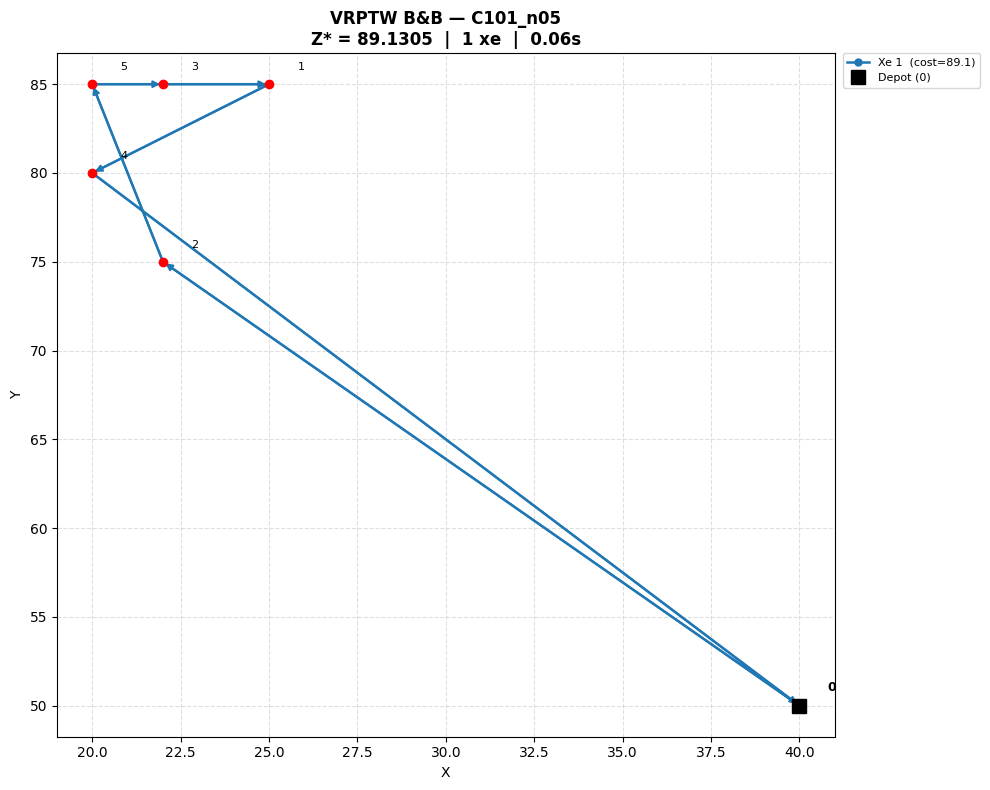


[*] Giải C101_n10  (time_limit=1800s) ...

  Instance C101_n10  |  n = 10 khách hàng
  Tổng chi phí (Z*)          : 185.9079
  Số xe sử dụng              : 2
  Số nút B&B đã duyệt        : 7931
  Cắt tỉa (infeasible)       : 2555
  Cắt tỉa (by bound)         : 1409
  Cắt tỉa (optimality/int)   : 2
  Thời gian chạy             : 20.9009s

  Chi tiết các tuyến:
    Xe  1: 0 -> 2 -> 5 -> 7 -> 6 -> 8 -> 3 -> 1 -> 4 -> 0  (cost = 115.7441)
    Xe  2: 0 -> 9 -> 10 -> 0  (cost = 70.1638)


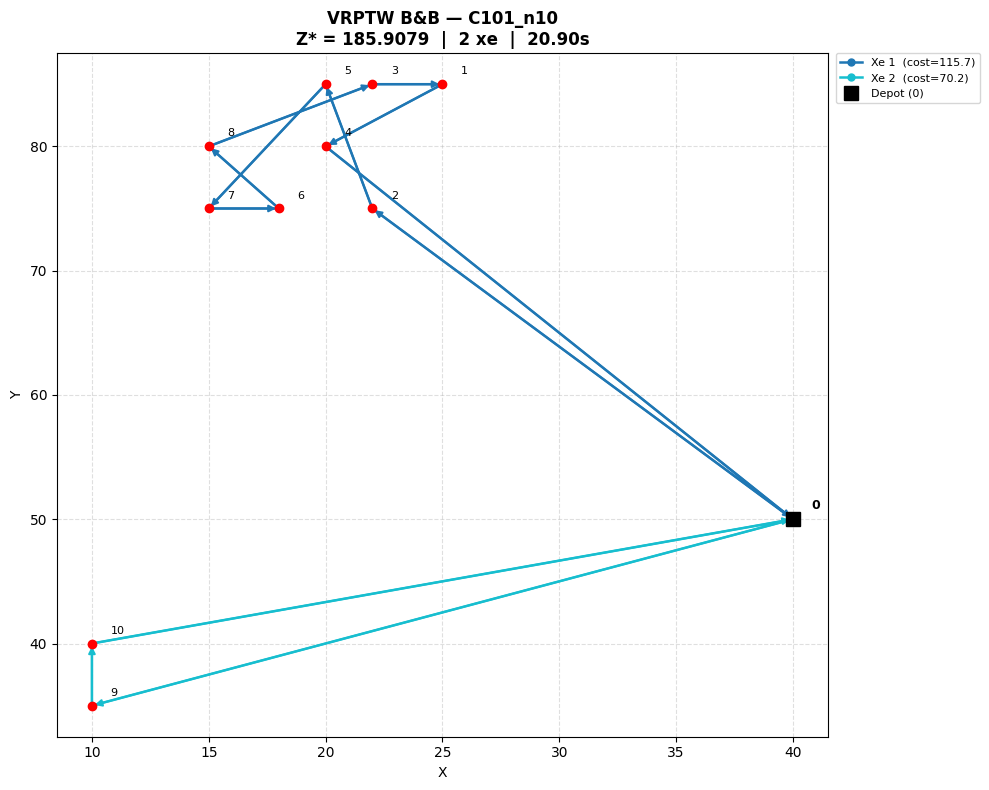



  KẾT QUẢ THỰC NGHIỆM — Branch and Bound (MILP) — Solomon C101
  Instance          Z* (tối ưu)   Số xe   Số nút B&B   T.gian (s)
  -------------- -------------- ------- ------------ ------------
  C101_n05              89.1305       1           25       0.0637
  C101_n10             185.9079       2         7931      20.9009



In [71]:
filepath = "F:\hoc_ki_2_nam_2025_2026\machine_learning\exercise\daa-project\data\RC101 (1).txt"
run_experiments(filepath)